In [1]:
import pandas as pd
import numpy as np

In [2]:
# Loading the datasets
arise = pd.read_csv("ARIES_Dataset.csv")
civic = pd.read_csv("CivicPulse_KS.csv")

print("ARISE shape:", arise.shape)
print("CivicPulse shape:", civic.shape)

display(arise.head())
display(civic.head())

ARISE shape: (309, 91)
CivicPulse shape: (135, 74)


,Unnamed: 0,ResponseId,RecipientLastName,ExternalReference,1st Dis,2nd Dis,3rd Dis,Q3_10_Agri,Q3_9_Cyber,Q3_19_Dam,...,Q13_Reduce staff,Q13_Defer capital projects,Q13_Reduce benefits,Q13_Reduce services,Q13_Increase taxes,Q13_Increase user fees,Q13_Adopt new fees,Q13_Reduce fund balance,Q13_Defer maintenance expenditures,Q13_None of the above
0,1,R_2sQNn7iItA9jdBn,chief administrator,2079950,3.0,21.0,1.0,NaN,NaN,NaN,...,1,1,1,0,1,1,1,0,0,0
1,2,R_2Qyp1YFLCR17M9C,chief administrator,2061250,11.0,3.0,8.0,NaN,NaN,NaN,...,1,1,0,1,1,0,0,0,1,0
2,3,R_2aQAihYklmvMFey,chief administrator,2005600,11.0,21.0,1.0,NaN,NaN,NaN,...,1,1,0,1,1,0,0,0,1,0
3,4,R_6sTVkGKJ3zy6aPL,chief administrator,2034300,21.0,1.0,2.0,NaN,NaN,NaN,...,0,1,0,0,1,0,0,0,0,0
4,5,R_3sddVtnZ4CSdNk0,chief administrator,2053225,3.0,1.0,23.0,NaN,NaN,NaN,...,1,1,1,1,1,1,1,1,1,0


,Respondentid,statecode,countycode,countysubcode,placecode,govname,state,stpl_fips,stco_fips,Roletype,...,Efficiency_GR_reduc,Efficiency_GR_worth,Efficiency_GR_maint,Efficiency_GR_resid,Efficiency_GR_people,Tenure_SC,Education_SC,Discipline_MS,Discipline_MS_other_TEXT,Party_SC
0,100203,20,107,.,56450,Pleasanton City,KS,2056450.0,20107.0,County/Municipal Policymaker,...,4.0,5.0,4.0,1.0,2.0,2.0,6.0,5,NaN,5.0
1,100799,20,173,.,44200,City Of Maize,KS,2044200.0,20173.0,County/Municipal Policymaker,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,108545,20,173,.,73250,City Of Valley Center,KS,2073250.0,20173.0,County/Municipal Policymaker,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,111722,20,043,.,76000,Wathena City,KS,2076000.0,20043.0,County/Municipal Policymaker,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,113753,20,091,.,19825,City Of Edgerton,KS,2019825.0,20091.0,County/Municipal Policymaker,...,2.0,2.0,2.0,2.0,1.0,2.0,5.0,3,NaN,6.0


In [3]:
# doing the variables names in laowercase and all the spaces and all changing with_
def clean_columns(df):
    df = df.copy()
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_", regex=False)
        .str.replace(".", "_", regex=False)
        .str.replace(",", "", regex=False)
        .str.replace("-", "_", regex=False)
        .str.replace("/", "_", regex=False)
    )
    return df

arise = clean_columns(arise)
civic = clean_columns(civic)

print("ARISE columns:")
print(arise.columns.tolist())

print("\nCivicPulse columns:")
print(civic.columns.tolist())

ARISE columns:
['unnamed:_0', 'responseid', 'recipientlastname', 'externalreference', '1st_dis', '2nd_dis', '3rd_dis', 'q3_10_agri', 'q3_9_cyber', 'q3_19_dam', 'q3_1_droughts', 'q3_12_earthquake', 'q3_2_heat', 'q3_3_floods', 'q3_4_ice', 'q3_7_waste_spill', 'q3_8_industrial_fire', 'q3_22_soil_erosion', 'q3_21_severe_storms', 'q3_17_terrorism', 'q3_5_tornados', 'q3_11_infrastructure_failure', 'q3_6_wildfires', 'q3_23_others', 'q3_23_text', 'q4_1', 'q4_2', 'q4_3', 'q4_4', 'q5', 'q6_7_text', 'q7', 'q8', 'q12_1', 'q12_2', 'q12_3', 'q12_4', 'q12_5', 'q12_6', 'q12_7', 'q119', 'q29', 'q30', 'q31', 'q6_1', 'q6_2', 'q6_3', 'q6_4', 'q6_5', 'q6_6', 'q6_7', 'q9_early_warning', 'q9_evacuation_plan', 'q9_financial_assistance_for_low_income_ac', 'q9_water_conservation_programs', 'q9_energy_conservation_programs', 'q9_zoning', 'q9_financial_assistance_for_low_income_shut_offs', 'q9_heating_or_cooling_stations', 'q9_tornado_shelter', 'q9_early_warning_lang', 'q9_code_enforcement', 'q9_backup_electric', 

In [4]:
# Basic Celaning of both datasets 
def basic_cleaning(df):
    df = df.copy()

    # Droping full empty rows and columns
    df = df.dropna(how="all")
    df = df.dropna(axis=1, how="all")

    # Replace common missing values
    missing_values = ["NA", "N/A", "na", "n/a", "", " ", "None", "null", "did not respond"]
    df = df.replace(missing_values, np.nan)

    # Removing duplicate rows
    df = df.drop_duplicates()

    # Strip spaces from text columns
    for col in df.select_dtypes(include="object").columns:
        df[col] = df[col].astype(str).str.strip()
        df[col] = df[col].replace("nan", np.nan)

    return df

arise = basic_cleaning(arise)
civic = basic_cleaning(civic)

print("ARISE cleaned shape:", arise.shape)
print("CivicPulse cleaned shape:", civic.shape)

ARISE cleaned shape: (309, 89)
CivicPulse cleaned shape: (135, 68)


In [5]:
# keeping the same name in both datasets for response id
arise = arise.rename(columns={"responseid": "id"})
civic = civic.rename(columns={"respondentid": "id"})

In [6]:
# counting the missing values in both datasets
print("ARISE missing values per column:")
display(arise.isnull().sum().sort_values(ascending=False).head(89))

print("Total missing values in ARISE dataset:")
print(arise.isnull().sum().sum())


print("\nCivicPulse missing values per column:")
display(civic.isnull().sum().sort_values(ascending=False).head(68))

print("Total missing values in CivicPulse dataset:")
print(civic.isnull().sum().sum())

ARISE missing values per column:


q3_19_dam                      306
q3_8_industrial_fire           305
q3_7_waste_spill               305
q3_10_agri                     302
q3_23_others                   301
                              ... 
q9_early_warning_lang            0
q9_code_enforcement              0
q9_backup_electric               0
q9_evacuation_route_or_plan      0
q13_none_of_the_above            0
Length: 89, dtype: int64

Total missing values in ARISE dataset:
5533

CivicPulse missing values per column:


mode_ms_other_text           134
leaders_ms_other_text        133
experiments_ms_other_text    132
impacts_ms_other_text        129
disaster_ms_other_text       129
                            ... 
govtype                        0
statecode                      0
stateabb                       0
countycode                     0
id                             0
Length: 68, dtype: int64

Total missing values in CivicPulse dataset:
3003


In [7]:
#Common Variable columns in both datasets
common_vars_map = {

"workforce_challenge_level": ["q8","workforce_sc"],
"fiscal_condition_overall": ["q119","condition_sc"],

"service_early_warning_available": ["q9_early_warning","services_gr_early"],
"service_backup_electric_available": ["q9_backup_electric","services_gr_backup"],
"service_evacuation_plan_available": ["q9_evacuation_route_or_plan","services_gr_evac"],
"service_utility_shutoff_assistance_available": ["q9_financial_assistance_for_low_income_shut_offs","services_gr_financial"],
"service_heating_cooling_stations_available": ["q9_heating_or_cooling_stations","services_gr_heating"],

"early_warning_multilingual": ["q9_early_warning_lang","early_sc"],
"evacuation_support_no_car_households": ["q9_evacuation_plan","evacuation_sc"],

"respondent_tenure_local_gov": ["q29","tenure_sc"],
"respondent_education_level": ["q30","education_sc"],

"equity_group_elderly_support": ["q10_elderly_people","groups_gr_elderly"],
"equity_group_low_income_support": ["q10_low_income","groups_gr_low"],
"equity_group_homeless_support": ["q10_homeless","groups_gr_homeless"],
"equity_group_non_english_support": ["q10_non_english","groups_gr_non"],

# Infrastructure finance variables
"infra_finance_spending_gap": ["q13_reduce_services","infra_gr_spending"],
"infra_finance_unstable_funding": ["q13_defer_capital_projects","infra_gr_relies"],
"infra_finance_budget_constraints": ["q13_reduce_fund_balance","infra_gr_budget"]

}

In [8]:
#Checking results above variables are present in both dataset or not
check_results = []

for harm_var, cols in common_vars_map.items():

    arise_col = cols[0]
    civic_col = cols[1]

    check_results.append({

        "harmonized_variable": harm_var,
        "arise_column": arise_col,
        "arise_exists": arise_col in arise.columns,
        "civic_column": civic_col,
        "civic_exists": civic_col in civic.columns

    })

check_df = pd.DataFrame(check_results)

display(check_df)

,harmonized_variable,arise_column,arise_exists,civic_column,civic_exists
0,workforce_challenge_level,q8,True,workforce_sc,True
1,fiscal_condition_overall,q119,True,condition_sc,True
2,service_early_warning_available,q9_early_warning,True,services_gr_early,True
3,service_backup_electric_available,q9_backup_electric,True,services_gr_backup,True
4,service_evacuation_plan_available,q9_evacuation_route_or_plan,True,services_gr_evac,True
5,service_utility_shutoff_assistance_available,q9_financial_assistance_for_low_income_shut_offs,True,services_gr_financial,True
6,service_heating_cooling_stations_available,q9_heating_or_cooling_stations,True,services_gr_heating,True
7,early_warning_multilingual,q9_early_warning_lang,True,early_sc,True
8,evacuation_support_no_car_households,q9_evacuation_plan,True,evacuation_sc,True
9,respondent_tenure_local_gov,q29,True,tenure_sc,True


In [9]:
# Saving the crosswalk table.
check_df.to_excel("harmonization_crosswalk_table.xlsx", index=False)

print("Crosswalk table saved successfully.")

Crosswalk table saved successfully.


In [10]:
# Created Harmonized varibles in both datasets
for harm_var, cols in common_vars_map.items():
    arise_col = cols[0]
    civic_col = cols[1]

    arise[harm_var] = arise[arise_col]
    civic[harm_var] = civic[civic_col]

In [11]:
#Checked the consistency in both datasets 
harm_vars = list(common_vars_map.keys())

print("Total Harmonized Variables:", len(harm_vars))

print("\nARISE harmonized columns:")
display(arise[harm_vars].head())

print("\nCIVIC harmonized columns:")
display(civic[harm_vars].head())

Total Harmonized Variables: 18

ARISE harmonized columns:


,workforce_challenge_level,fiscal_condition_overall,service_early_warning_available,service_backup_electric_available,service_evacuation_plan_available,service_utility_shutoff_assistance_available,service_heating_cooling_stations_available,early_warning_multilingual,evacuation_support_no_car_households,respondent_tenure_local_gov,respondent_education_level,equity_group_elderly_support,equity_group_low_income_support,equity_group_homeless_support,equity_group_non_english_support,infra_finance_spending_gap,infra_finance_unstable_funding,infra_finance_budget_constraints
0,3.0,3.0,0,1,0,0,0,0,0,3.0,6.0,0,0,0,0,0,1,0
1,4.0,4.0,1,1,1,0,0,0,0,3.0,5.0,0,0,0,0,1,1,0
2,5.0,4.0,1,1,0,1,0,0,0,6.0,6.0,0,0,0,0,1,1,0
3,3.0,3.0,1,1,0,1,1,0,0,3.0,6.0,1,1,0,0,0,1,0
4,3.0,3.0,1,0,0,0,0,0,0,4.0,6.0,0,0,0,0,1,1,1



CIVIC harmonized columns:


,workforce_challenge_level,fiscal_condition_overall,service_early_warning_available,service_backup_electric_available,service_evacuation_plan_available,service_utility_shutoff_assistance_available,service_heating_cooling_stations_available,early_warning_multilingual,evacuation_support_no_car_households,respondent_tenure_local_gov,respondent_education_level,equity_group_elderly_support,equity_group_low_income_support,equity_group_homeless_support,equity_group_non_english_support,infra_finance_spending_gap,infra_finance_unstable_funding,infra_finance_budget_constraints
0,4.0,2.0,1,1,5,5,1,2.0,NaN,2.0,6.0,1.0,2.0,1.0,3.0,2.0,2.0,1.0
1,4.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,3.0,5.0
2,2.0,4.0,1,1,1,1,1,1.0,3.0,NaN,NaN,3.0,3.0,3.0,4.0,2.0,3.0,2.0
3,4.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,4.0,1.0
4,1.0,5.0,3,1,3,"1,3,4",1,3.0,3.0,2.0,5.0,4.0,3.0,1.0,2.0,5.0,4.0,4.0


In [12]:
# Adding common Variable columns in actual civicpulse dataset
for harm_var, cols in common_vars_map.items():

    civic_col = cols[1]

    civic[harm_var] = civic[civic_col]

print("Updated CIVIC dataset shape:", civic.shape)
display(civic.head())

Updated CIVIC dataset shape: (135, 86)


,id,statecode,countycode,countysubcode,placecode,govname,state,stpl_fips,stco_fips,roletype,...,evacuation_support_no_car_households,respondent_tenure_local_gov,respondent_education_level,equity_group_elderly_support,equity_group_low_income_support,equity_group_homeless_support,equity_group_non_english_support,infra_finance_spending_gap,infra_finance_unstable_funding,infra_finance_budget_constraints
0,100203,20,107,.,56450,Pleasanton City,KS,2056450.0,20107.0,County/Municipal Policymaker,...,NaN,2.0,6.0,1.0,2.0,1.0,3.0,2.0,2.0,1.0
1,100799,20,173,.,44200,City Of Maize,KS,2044200.0,20173.0,County/Municipal Policymaker,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,3.0,5.0
2,108545,20,173,.,73250,City Of Valley Center,KS,2073250.0,20173.0,County/Municipal Policymaker,...,3.0,NaN,NaN,3.0,3.0,3.0,4.0,2.0,3.0,2.0
3,111722,20,043,.,76000,Wathena City,KS,2076000.0,20043.0,County/Municipal Policymaker,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,4.0,1.0
4,113753,20,091,.,19825,City Of Edgerton,KS,2019825.0,20091.0,County/Municipal Policymaker,...,3.0,2.0,5.0,4.0,3.0,1.0,2.0,5.0,4.0,4.0


In [13]:
#Adding common variable columns in actual arise dataset
for harm_var, cols in common_vars_map.items():

    arise_col = cols[0]

    arise[harm_var] = arise[arise_col]

print("Updated ARISE dataset shape:", arise.shape)
display(arise.head())

Updated ARISE dataset shape: (309, 107)


,unnamed:_0,id,recipientlastname,externalreference,1st_dis,2nd_dis,3rd_dis,q3_10_agri,q3_9_cyber,q3_19_dam,...,evacuation_support_no_car_households,respondent_tenure_local_gov,respondent_education_level,equity_group_elderly_support,equity_group_low_income_support,equity_group_homeless_support,equity_group_non_english_support,infra_finance_spending_gap,infra_finance_unstable_funding,infra_finance_budget_constraints
0,1,R_2sQNn7iItA9jdBn,chief administrator,2079950,3.0,21.0,1.0,NaN,NaN,NaN,...,0,3.0,6.0,0,0,0,0,0,1,0
1,2,R_2Qyp1YFLCR17M9C,chief administrator,2061250,11.0,3.0,8.0,NaN,NaN,NaN,...,0,3.0,5.0,0,0,0,0,1,1,0
2,3,R_2aQAihYklmvMFey,chief administrator,2005600,11.0,21.0,1.0,NaN,NaN,NaN,...,0,6.0,6.0,0,0,0,0,1,1,0
3,4,R_6sTVkGKJ3zy6aPL,chief administrator,2034300,21.0,1.0,2.0,NaN,NaN,NaN,...,0,3.0,6.0,1,1,0,0,0,1,0
4,5,R_3sddVtnZ4CSdNk0,chief administrator,2053225,3.0,1.0,23.0,NaN,NaN,NaN,...,0,4.0,6.0,0,0,0,0,1,1,1


In [14]:
# Saving the new harmonized datesests.
arise.to_excel("arise_harmonized.xlsx", index=False)
civic.to_excel("civicpulse_harmonized.xlsx", index=False)

print("Excel files saved successfully.")

Excel files saved successfully.


In [15]:
#List of harmonized variables
harm_vars = list(common_vars_map.keys())

print("Total harmonized variables:", len(harm_vars))
print(harm_vars)

Total harmonized variables: 18
['workforce_challenge_level', 'fiscal_condition_overall', 'service_early_warning_available', 'service_backup_electric_available', 'service_evacuation_plan_available', 'service_utility_shutoff_assistance_available', 'service_heating_cooling_stations_available', 'early_warning_multilingual', 'evacuation_support_no_car_households', 'respondent_tenure_local_gov', 'respondent_education_level', 'equity_group_elderly_support', 'equity_group_low_income_support', 'equity_group_homeless_support', 'equity_group_non_english_support', 'infra_finance_spending_gap', 'infra_finance_unstable_funding', 'infra_finance_budget_constraints']


In [16]:
#Added source column
arise["source"] = "ARISE"
civic["source"] = "CivicPulse"

In [17]:
#Kept only harmonized variables + source
arise_harmonized_only = arise[harm_vars + ["source"]].copy()
civic_harmonized_only = civic[harm_vars + ["source"]].copy()

In [18]:
#Check shapes
print("ARISE harmonized dataset shape:", arise_harmonized_only.shape)
print("CivicPulse harmonized dataset shape:", civic_harmonized_only.shape)

print("\nARISE harmonized columns:")
print(arise_harmonized_only.columns.tolist())

print("\nCivicPulse harmonized columns:")
print(civic_harmonized_only.columns.tolist())

ARISE harmonized dataset shape: (309, 19)
CivicPulse harmonized dataset shape: (135, 19)

ARISE harmonized columns:
['workforce_challenge_level', 'fiscal_condition_overall', 'service_early_warning_available', 'service_backup_electric_available', 'service_evacuation_plan_available', 'service_utility_shutoff_assistance_available', 'service_heating_cooling_stations_available', 'early_warning_multilingual', 'evacuation_support_no_car_households', 'respondent_tenure_local_gov', 'respondent_education_level', 'equity_group_elderly_support', 'equity_group_low_income_support', 'equity_group_homeless_support', 'equity_group_non_english_support', 'infra_finance_spending_gap', 'infra_finance_unstable_funding', 'infra_finance_budget_constraints', 'source']

CivicPulse harmonized columns:
['workforce_challenge_level', 'fiscal_condition_overall', 'service_early_warning_available', 'service_backup_electric_available', 'service_evacuation_plan_available', 'service_utility_shutoff_assistance_available',

In [19]:
#Combine both datasets
combined_harmonized = pd.concat(
    [arise_harmonized_only, civic_harmonized_only],
    ignore_index=True
)

In [21]:
#Checked combined output
print("Combined harmonized dataset shape:", combined_harmonized.shape)
display(combined_harmonized.head())
display(combined_harmonized.tail())

Combined harmonized dataset shape: (444, 19)


,workforce_challenge_level,fiscal_condition_overall,service_early_warning_available,service_backup_electric_available,service_evacuation_plan_available,service_utility_shutoff_assistance_available,service_heating_cooling_stations_available,early_warning_multilingual,evacuation_support_no_car_households,respondent_tenure_local_gov,respondent_education_level,equity_group_elderly_support,equity_group_low_income_support,equity_group_homeless_support,equity_group_non_english_support,infra_finance_spending_gap,infra_finance_unstable_funding,infra_finance_budget_constraints,source
0,3.0,3.0,0,1,0,0,0,0.0,0.0,3.0,6.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,ARISE
1,4.0,4.0,1,1,1,0,0,0.0,0.0,3.0,5.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,ARISE
2,5.0,4.0,1,1,0,1,0,0.0,0.0,6.0,6.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,ARISE
3,3.0,3.0,1,1,0,1,1,0.0,0.0,3.0,6.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,ARISE
4,3.0,3.0,1,0,0,0,0,0.0,0.0,4.0,6.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,ARISE


,workforce_challenge_level,fiscal_condition_overall,service_early_warning_available,service_backup_electric_available,service_evacuation_plan_available,service_utility_shutoff_assistance_available,service_heating_cooling_stations_available,early_warning_multilingual,evacuation_support_no_car_households,respondent_tenure_local_gov,respondent_education_level,equity_group_elderly_support,equity_group_low_income_support,equity_group_homeless_support,equity_group_non_english_support,infra_finance_spending_gap,infra_finance_unstable_funding,infra_finance_budget_constraints,source
439,3.0,3.0,3,1,1,4,1,3.0,2.0,2.0,7.0,3.0,2.0,2.0,2.0,2.0,5.0,1.0,CivicPulse
440,4.0,4.0,3,3,3,5,3,3.0,3.0,5.0,5.0,4.0,3.0,4.0,3.0,2.0,5.0,5.0,CivicPulse
441,4.0,2.0,1,5,3,4,1,3.0,3.0,3.0,2.0,4.0,1.0,1.0,3.0,1.0,5.0,2.0,CivicPulse
442,5.0,3.0,3,5,5,4,5,2.0,NaN,3.0,7.0,1.0,1.0,6.0,6.0,2.0,2.0,1.0,CivicPulse
443,5.0,2.0,"1,3",5,"1,3",4,5,1.0,3.0,2.0,3.0,5.0,5.0,5.0,5.0,1.0,1.0,1.0,CivicPulse


In [22]:
#Check source counts
print(combined_harmonized["source"].value_counts())

source
ARISE         309
CivicPulse    135
Name: count, dtype: int64


In [23]:
#Check missing values
print("Missing values in combined dataset:")
display(combined_harmonized.isnull().sum().sort_values(ascending=False))

Missing values in combined dataset:


respondent_education_level                      129
respondent_tenure_local_gov                     128
fiscal_condition_overall                         72
evacuation_support_no_car_households             67
equity_group_homeless_support                    42
equity_group_non_english_support                 41
equity_group_low_income_support                  41
equity_group_elderly_support                     41
workforce_challenge_level                        37
early_warning_multilingual                       33
service_backup_electric_available                30
service_heating_cooling_stations_available       27
service_evacuation_plan_available                27
service_early_warning_available                  27
service_utility_shutoff_assistance_available     25
infra_finance_spending_gap                       17
infra_finance_unstable_funding                   17
infra_finance_budget_constraints                 17
source                                            0
dtype: int64

In [24]:
#Save file
combined_harmonized.to_excel("combined_harmonized_dataset.xlsx", index=False)
print("Combined harmonized dataset saved successfully.")

Combined harmonized dataset saved successfully.


In [25]:
#Checked structure
print("Combined dataset shape:", combined_harmonized.shape)
print("\nColumns in combined dataset:")
print(combined_harmonized.columns.tolist())
display(combined_harmonized.head())

Combined dataset shape: (444, 19)

Columns in combined dataset:
['workforce_challenge_level', 'fiscal_condition_overall', 'service_early_warning_available', 'service_backup_electric_available', 'service_evacuation_plan_available', 'service_utility_shutoff_assistance_available', 'service_heating_cooling_stations_available', 'early_warning_multilingual', 'evacuation_support_no_car_households', 'respondent_tenure_local_gov', 'respondent_education_level', 'equity_group_elderly_support', 'equity_group_low_income_support', 'equity_group_homeless_support', 'equity_group_non_english_support', 'infra_finance_spending_gap', 'infra_finance_unstable_funding', 'infra_finance_budget_constraints', 'source']


,workforce_challenge_level,fiscal_condition_overall,service_early_warning_available,service_backup_electric_available,service_evacuation_plan_available,service_utility_shutoff_assistance_available,service_heating_cooling_stations_available,early_warning_multilingual,evacuation_support_no_car_households,respondent_tenure_local_gov,respondent_education_level,equity_group_elderly_support,equity_group_low_income_support,equity_group_homeless_support,equity_group_non_english_support,infra_finance_spending_gap,infra_finance_unstable_funding,infra_finance_budget_constraints,source
0,3.0,3.0,0,1,0,0,0,0.0,0.0,3.0,6.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,ARISE
1,4.0,4.0,1,1,1,0,0,0.0,0.0,3.0,5.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,ARISE
2,5.0,4.0,1,1,0,1,0,0.0,0.0,6.0,6.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,ARISE
3,3.0,3.0,1,1,0,1,1,0.0,0.0,3.0,6.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,ARISE
4,3.0,3.0,1,0,0,0,0,0.0,0.0,4.0,6.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,ARISE


In [26]:
#Summary statistics
print("Summary statistics for harmonized variables:")
display(combined_harmonized.describe(include="all"))

Summary statistics for harmonized variables:


,workforce_challenge_level,fiscal_condition_overall,service_early_warning_available,service_backup_electric_available,service_evacuation_plan_available,service_utility_shutoff_assistance_available,service_heating_cooling_stations_available,early_warning_multilingual,evacuation_support_no_car_households,respondent_tenure_local_gov,respondent_education_level,equity_group_elderly_support,equity_group_low_income_support,equity_group_homeless_support,equity_group_non_english_support,infra_finance_spending_gap,infra_finance_unstable_funding,infra_finance_budget_constraints,source
count,407.000000,372.000000,417.0,414.0,417.0,419.0,417.0,411.000000,377.000000,316.000000,315.000000,403.000000,403.000000,402.000000,403.000000,427.000000,427.000000,427.000000,444
unique,NaN,NaN,11.0,11.0,11.0,10.0,8.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
top,NaN,NaN,1.0,1.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ARISE
freq,NaN,NaN,248.0,185.0,193.0,219.0,227.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,309
mean,3.407862,3.704301,NaN,NaN,NaN,NaN,NaN,0.627737,0.546419,3.943038,4.739683,0.933002,0.836228,0.713930,0.692308,0.836066,1.283372,0.737705,NaN
std,1.041379,0.919207,NaN,NaN,NaN,NaN,NaN,1.038343,0.980444,1.491749,1.448318,1.422274,1.392223,1.501539,1.340014,1.365680,1.597175,1.149222,NaN
min,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
25%,3.000000,3.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,3.000000,3.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
50%,3.000000,4.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,4.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,NaN
75%,4.000000,4.000000,NaN,NaN,NaN,NaN,NaN,1.000000,1.000000,5.000000,6.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000,NaN


In [27]:
#Compared all numeric variables by source
comparison_means = combined_harmonized.groupby("source").mean(numeric_only=True)
print("Average values by source:")
display(comparison_means)

Average values by source:


,workforce_challenge_level,fiscal_condition_overall,early_warning_multilingual,evacuation_support_no_car_households,respondent_tenure_local_gov,respondent_education_level,equity_group_elderly_support,equity_group_low_income_support,equity_group_homeless_support,equity_group_non_english_support,infra_finance_spending_gap,infra_finance_unstable_funding,infra_finance_budget_constraints
source,,,,,,,,,,,,,
ARISE,3.582418,3.767717,0.077670,0.139159,4.169565,4.550218,0.245955,0.165049,0.055016,0.061489,0.097087,0.398058,0.152104
CivicPulse,3.052239,3.567797,2.294118,2.397059,3.337209,5.244186,3.191489,3.042553,2.903226,2.765957,2.771186,3.601695,2.271186


In [28]:
#Compared key variables only
key_vars = [
    "workforce_challenge_level",
    "fiscal_condition_overall",
    "infra_finance_spending_gap",
    "infra_finance_unstable_funding",
    "infra_finance_budget_constraints"
]

key_var_comparison = combined_harmonized.groupby("source")[key_vars].mean()
print("Key variable comparison by source:")
display(key_var_comparison)

Key variable comparison by source:


,workforce_challenge_level,fiscal_condition_overall,infra_finance_spending_gap,infra_finance_unstable_funding,infra_finance_budget_constraints
source,,,,,
ARISE,3.582418,3.767717,0.097087,0.398058,0.152104
CivicPulse,3.052239,3.567797,2.771186,3.601695,2.271186


In [29]:
#Frequency distributions
for col in key_vars:
    print(f"\nFrequency distribution for {col}:")
    display(pd.crosstab(combined_harmonized[col], combined_harmonized["source"]))


Frequency distribution for workforce_challenge_level:


source,ARISE,CivicPulse
workforce_challenge_level,,
1.0,6,9
2.0,32,31
3.0,85,48
4.0,97,36
5.0,53,10



Frequency distribution for fiscal_condition_overall:


source,ARISE,CivicPulse
fiscal_condition_overall,,
1.0,6,1
2.0,12,15
3.0,69,36
4.0,115,48
5.0,52,18



Frequency distribution for infra_finance_spending_gap:


source,ARISE,CivicPulse
infra_finance_spending_gap,,
0.0,279,0
1.0,30,13
2.0,0,46
3.0,0,24
4.0,0,25
5.0,0,10



Frequency distribution for infra_finance_unstable_funding:


source,ARISE,CivicPulse
infra_finance_unstable_funding,,
0.0,186,0
1.0,123,3
2.0,0,17
3.0,0,32
4.0,0,38
5.0,0,28



Frequency distribution for infra_finance_budget_constraints:


source,ARISE,CivicPulse
infra_finance_budget_constraints,,
0.0,262,0
1.0,47,27
2.0,0,55
3.0,0,21
4.0,0,7
5.0,0,8


In [30]:
#Missing values
print("Missing values in combined dataset:")
display(combined_harmonized.isnull().sum().sort_values(ascending=False))

Missing values in combined dataset:


respondent_education_level                      129
respondent_tenure_local_gov                     128
fiscal_condition_overall                         72
evacuation_support_no_car_households             67
equity_group_homeless_support                    42
equity_group_non_english_support                 41
equity_group_low_income_support                  41
equity_group_elderly_support                     41
workforce_challenge_level                        37
early_warning_multilingual                       33
service_backup_electric_available                30
service_heating_cooling_stations_available       27
service_evacuation_plan_available                27
service_early_warning_available                  27
service_utility_shutoff_assistance_available     25
infra_finance_spending_gap                       17
infra_finance_unstable_funding                   17
infra_finance_budget_constraints                 17
source                                            0
dtype: int64

In [31]:
#Correlation matrix
correlation_matrix = combined_harmonized[key_vars].corr()
print("Correlation matrix:")
display(correlation_matrix)

Correlation matrix:


,workforce_challenge_level,fiscal_condition_overall,infra_finance_spending_gap,infra_finance_unstable_funding,infra_finance_budget_constraints
workforce_challenge_level,1.000000,-0.194502,-0.247250,-0.204849,-0.217129
fiscal_condition_overall,-0.194502,1.000000,-0.035949,-0.039560,0.010186
infra_finance_spending_gap,-0.247250,-0.035949,1.000000,0.833871,0.811613
infra_finance_unstable_funding,-0.204849,-0.039560,0.833871,1.000000,0.825829
infra_finance_budget_constraints,-0.217129,0.010186,0.811613,0.825829,1.000000


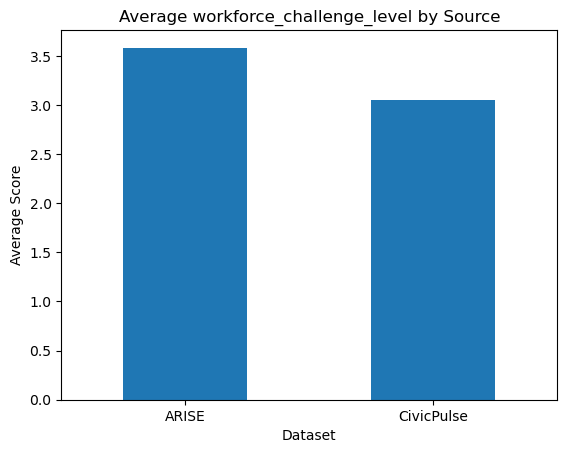

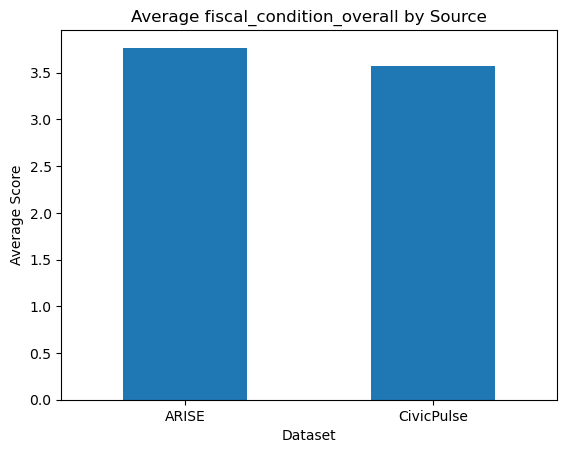

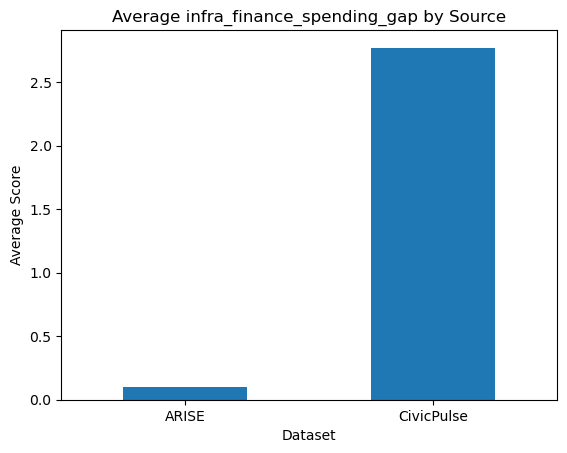

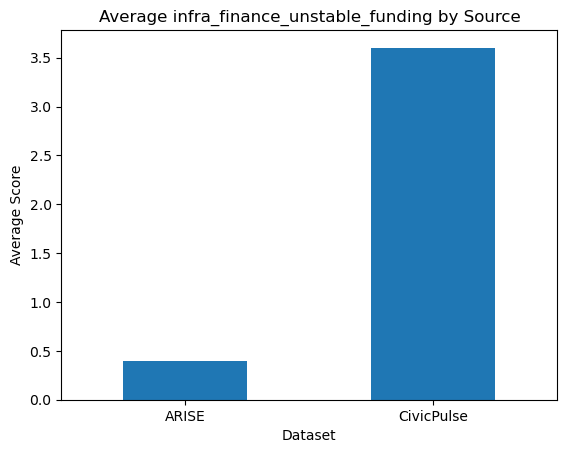

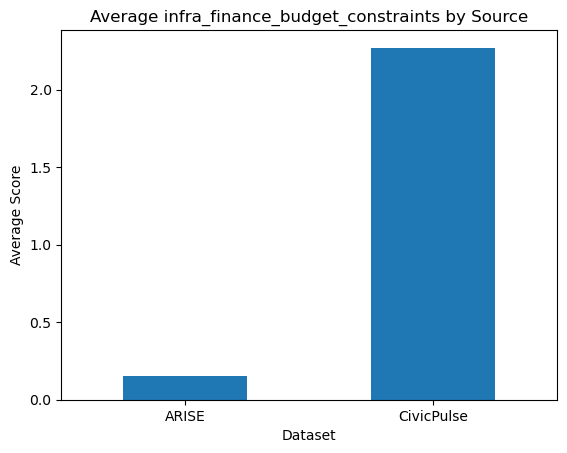

In [32]:
#Bar charts
import matplotlib.pyplot as plt
for col in key_vars:
    combined_harmonized.groupby("source")[col].mean().plot(kind="bar")
    plt.title(f"Average {col} by Source")
    plt.ylabel("Average Score")
    plt.xlabel("Dataset")
    plt.xticks(rotation=0)
    plt.show()

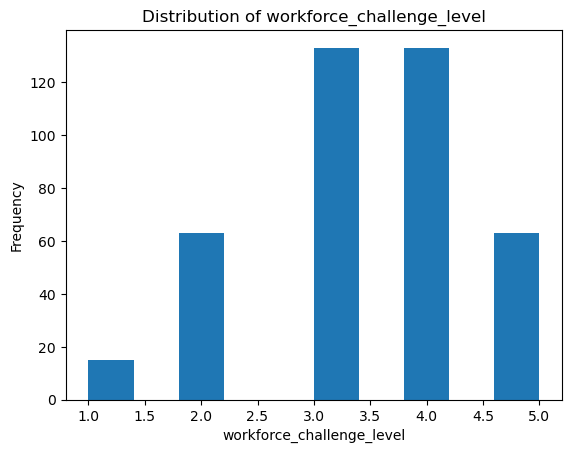

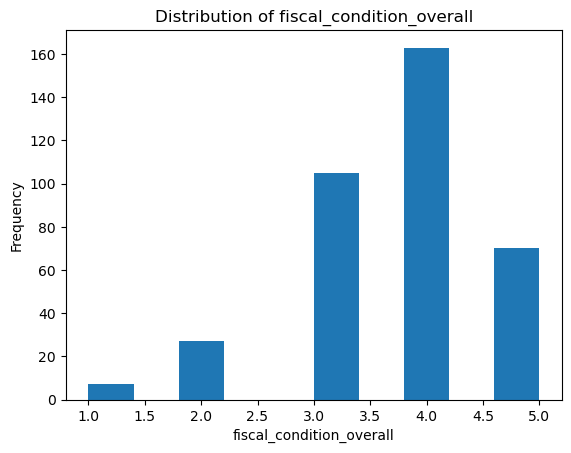

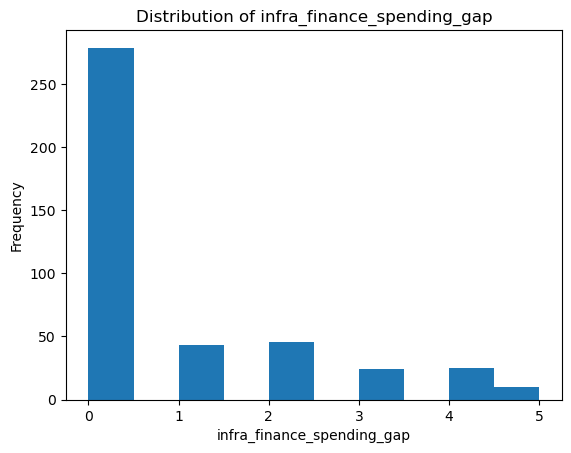

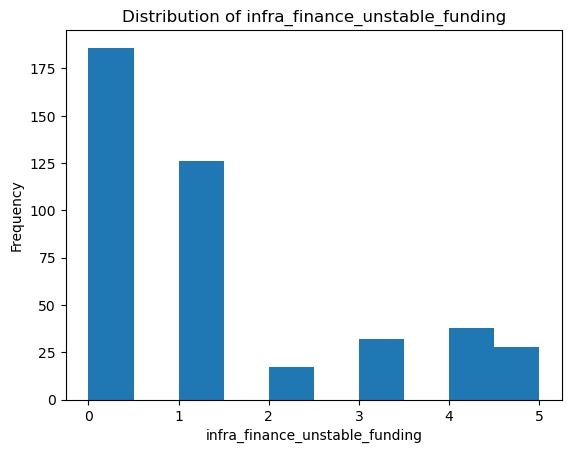

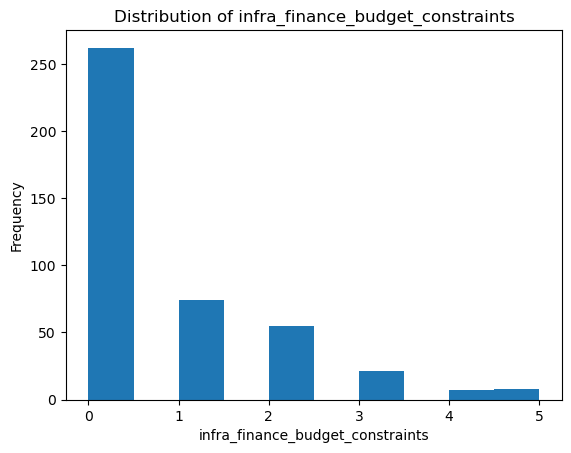

In [33]:
#Histograms
for col in key_vars:
    combined_harmonized[col].plot(kind="hist", bins=10)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

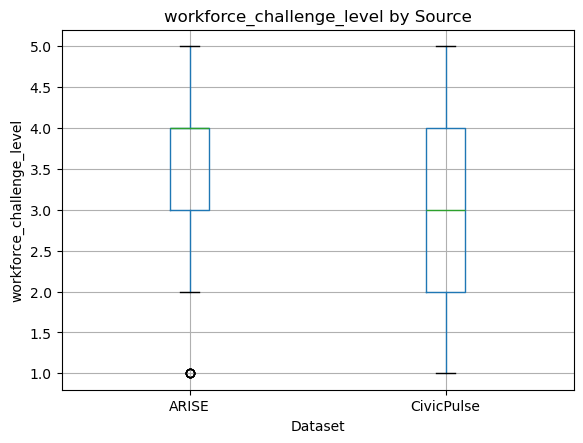

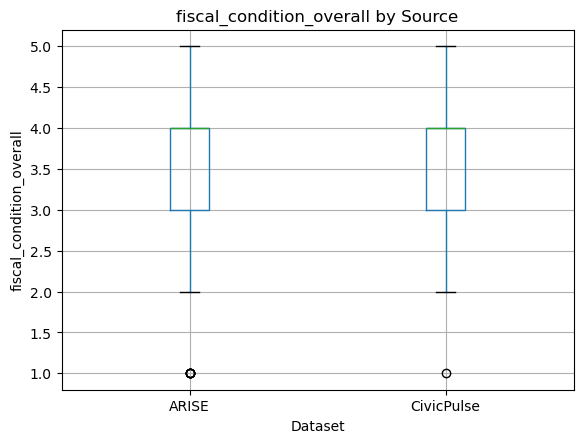

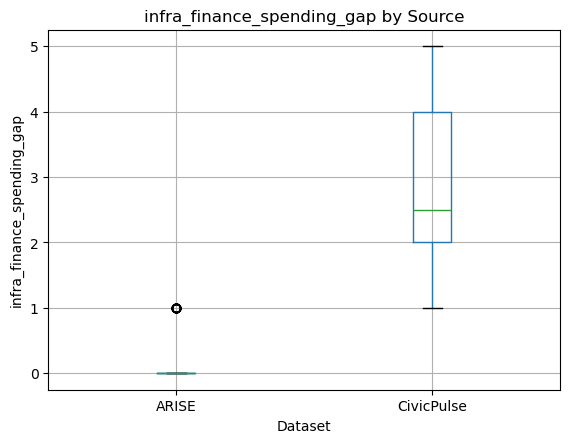

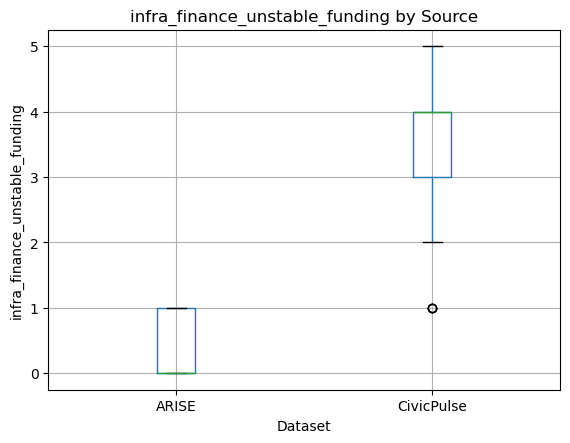

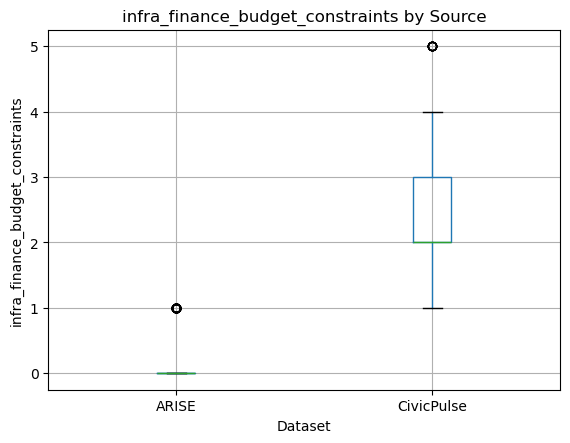

In [34]:
#Boxplots
for col in key_vars:
    combined_harmonized.boxplot(column=col, by="source")
    plt.title(f"{col} by Source")
    plt.suptitle("")
    plt.xlabel("Dataset")
    plt.ylabel(col)
    plt.show()

In [36]:
#Saved analysis results
with pd.ExcelWriter("analysis_outputs.xlsx") as writer:
    comparison_means.to_excel(writer, sheet_name="All_Means")
    key_var_comparison.to_excel(writer, sheet_name="Key_Variable_Means")
    correlation_matrix.to_excel(writer, sheet_name="Correlations")

In [37]:
print("Analysis outputs saved successfully.")

Analysis outputs saved successfully.
